## Pertpy cell type priorization with Augur

This script was to generate the mean augur score for endothelial cell types comparing IPF mild vs Control.

In [1]:
import scanpy as sc
import pertpy as pt
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/pytorch_lightning/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package

Running Scanpy 1.11.4, on 2026-08-27 09:22.


In [2]:
print(pt.__version__)

1.0.1


In [3]:
## plotting variables
plot_folder = "/media/synology/Huijuan/Plots/IPF_subsets/Augurpy/"
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['pdf.fonttype'] = 42

In [4]:
object_folder = "/media/HDD_1/sc_data_objects/FibFoci/"
adata = sc.read(object_folder + "18082026_snRNA_IPF_annotation_final.h5ad") 

## Endothelial

In [5]:
## have a look at the adata object
adata = adata[adata.obs.Level_1.isin(["Endothelial"])].copy()
adata

AnnData object with n_obs × n_vars = 11430 × 31116
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'souporcell_assignment', 'souporcell_singlet_posterior', 'souporcell_doublet_posterior', 'souporcell_log_prob_singleton', 'souporcell_log_prob_doublet', 'souporcell_cluster0', 'souporcell_cluster1', 'souporcell_cluster2', 'ident', 'sum', 'detected', 'subsets_Ribo_sum', 'subsets_Ribo_detected', 'subsets_Ribo_percent', 'total', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', '_scvi_batch', '_scvi_labels', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'souporcell_cluster3', 'sex', 'batch', 'Level_1', 'Level_2', 'Level_3', 'cell_type', 'severity', 'name', 'meta', 'ashcroft score', 'fibrosis extent', 'surface density'
    var: 'name', 'highly_variable', 

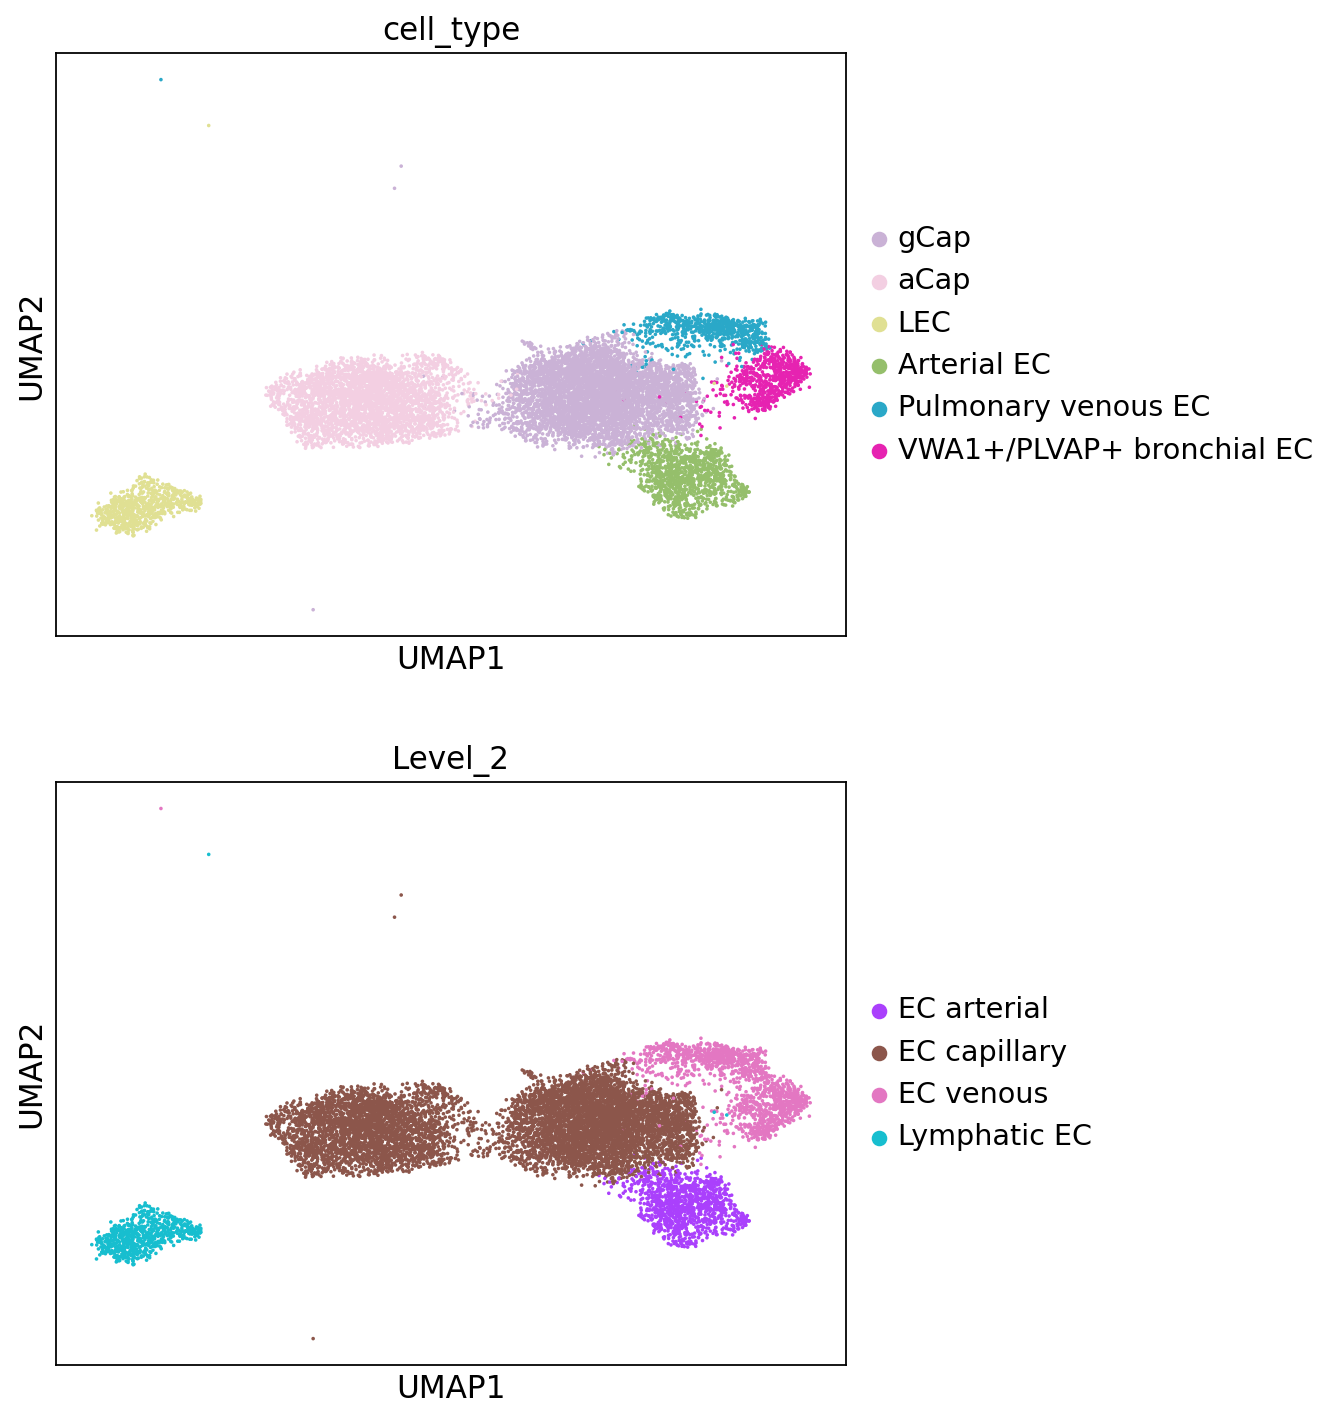

In [6]:
## overview UMAPs
sc.pl.umap(adata, color = ['cell_type', 'Level_2'], ncols = 1)

In [7]:
pd.crosstab(adata.obs['severity'],adata.obs['cell_type'])

cell_type,gCap,aCap,LEC,Arterial EC,Pulmonary venous EC,VWA1+/PLVAP+ bronchial EC
severity,,,,,,
Control,2781,1443,337,630,360,95
IPFMild,1783,1526,202,318,274,205
IPFSevere,400,214,184,188,94,396


In [8]:
#adata.obs.rename(columns = {'cell_type': 'cell_type_resolved'}, inplace=True)

In [9]:
## random forest classifier for categorical 'age_treatment' variable
ag_rfc = pt.tl.Augur("random_forest_classifier")

In [10]:
adata = adata[adata.obs.severity.isin(['Control','IPFMild'])].copy()

In [11]:
adata.obs.severity.value_counts()

severity
Control    5646
IPFMild    4308
Name: count, dtype: int64

In [12]:
loaded_data = ag_rfc.load(adata, label_col="severity", cell_type_col="cell_type")
loaded_data

AnnData object with n_obs × n_vars = 9954 × 31116
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'souporcell_assignment', 'souporcell_singlet_posterior', 'souporcell_doublet_posterior', 'souporcell_log_prob_singleton', 'souporcell_log_prob_doublet', 'souporcell_cluster0', 'souporcell_cluster1', 'souporcell_cluster2', 'ident', 'sum', 'detected', 'subsets_Ribo_sum', 'subsets_Ribo_detected', 'subsets_Ribo_percent', 'total', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', '_scvi_batch', '_scvi_labels', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'souporcell_cluster3', 'sex', 'batch', 'Level_1', 'Level_2', 'Level_3', 'cell_type', 'label', 'name', 'meta', 'ashcroft score', 'fibrosis extent', 'surface density', 'y_'
    var: 'name', 'highly_variable'

In [13]:
loaded_data.var['name'] = loaded_data.var_names

In [14]:
v_adata, v_results = ag_rfc.predict(
    loaded_data, n_subsamples=17, subsample_size=20, n_threads=32, select_variance_features=True)

v_results["summary_metrics"]

! Set smaller span value in the case of a `segmentation fault` error.
! Set larger span in case of svddc or other near singularities error.


Output()

/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/

,aCap,Pulmonary venous EC,gCap,Arterial EC,VWA1+/PLVAP+ bronchial EC,LEC
mean_augur_score,0.869348,0.780512,0.799353,0.669935,0.690343,0.609177
mean_auc,0.869348,0.780512,0.799353,0.669935,0.690343,0.609177
mean_accuracy,0.623465,0.610537,0.629929,0.589744,0.583818,0.551174
mean_precision,0.825163,0.670868,0.794865,0.708800,0.632190,0.569756
mean_f1,0.385553,0.400048,0.429381,0.405670,0.301891,0.378698
mean_recall,0.269374,0.313725,0.327731,0.328198,0.225957,0.314192


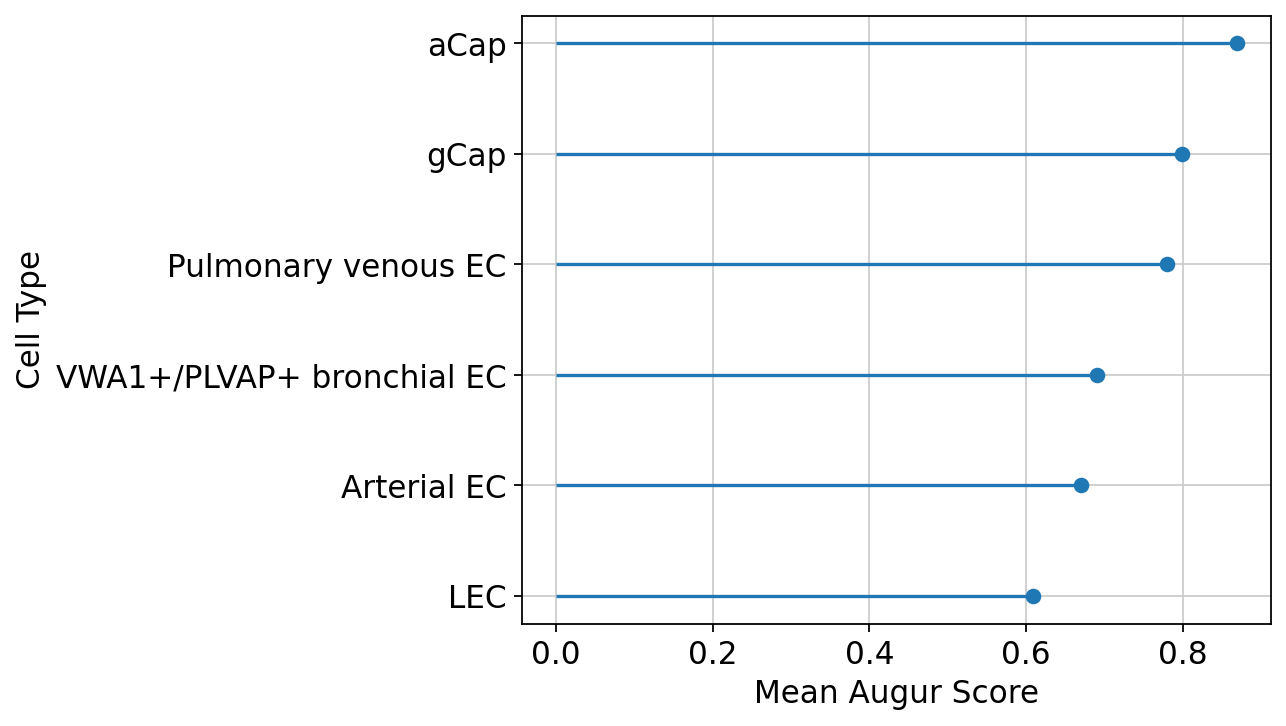

In [15]:
# a lollipop plot showing how well each cell type can distinguish between conditions (e.g., Disease vs Healthy), based on their transcriptional profiles
ag_rfc.plot_lollipop(v_results)  # Just call it, don't assign to a variable

#plt.xlim([0.45, 0.65])
#plt.xticks(np.arange(0.45, 0.65, step=0.05))
plt.grid(False)
#plt.savefig(plot_folder + 'pertpy_progressive_vs_stable_level3.pdf')
plt.close()

computing neighbors


/home/huijuanwang/miniconda3/envs/milopy/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:17)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:09)


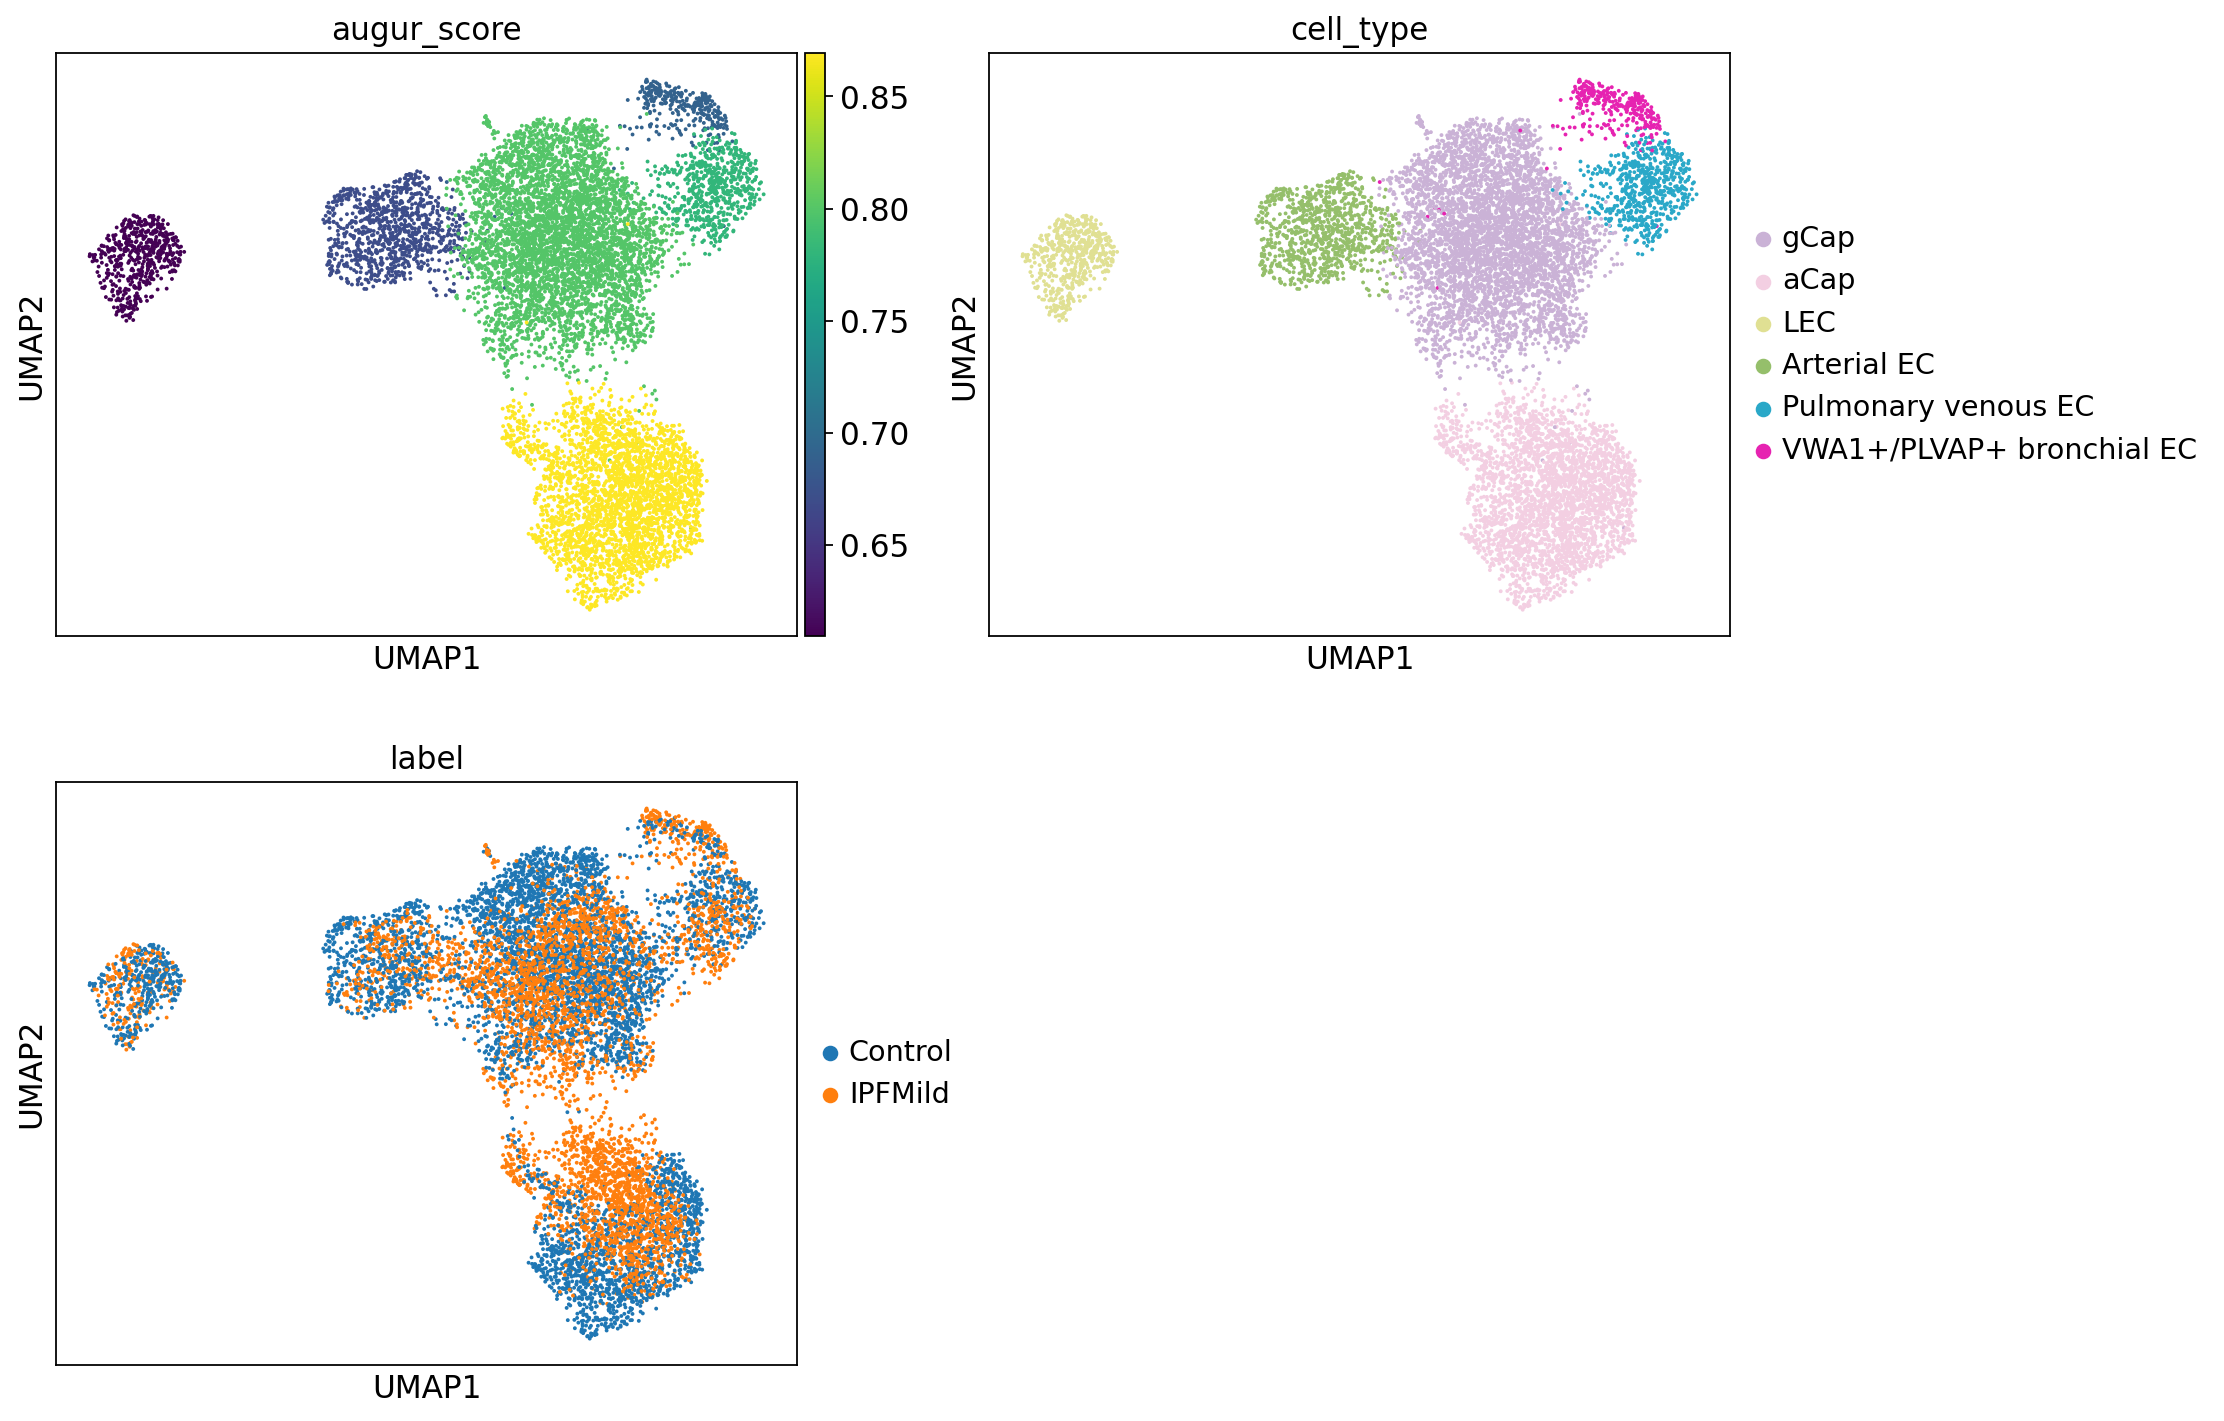

In [16]:
sc.pp.neighbors(v_adata, use_rep="X_scVI")
sc.tl.umap(v_adata)
sc.pl.umap(adata=v_adata, color=["augur_score", "cell_type", "label"], ncols=2)

### write augur score tables

In [17]:
v_scores = v_results['summary_metrics'].loc['mean_augur_score',]

In [18]:
v_scores = pd.DataFrame(v_scores)

In [19]:
## Save the Marker Table
out_folder = "/media/synology/Huijuan/Plots/IPF_subsets/"
v_scores.to_csv(out_folder + "snRNA_IPF_control_mild_augur_scores_celltype_EC.txt", sep = "\t")